# Task A2 — Lagged Exposure Analysis Across Mutations
### Do different mutations exhibit different spatiotemporal relay timescales (how quickly does activation propagate from neighbor to focal cell)?

#### 1. Imports and paths

In [ ]:
from pathlib import Path
import sys
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
DATA_PATH = PROJECT_ROOT / "data" / "single-cell-tracks_exp1-6_noErbB2.csv.gz"
META_PATH = PROJECT_ROOT / "data" / "01-readme-experiment-description_2022-04-05.csv"

OUTPUT_ROOT = PROJECT_ROOT / "analysis_outputs"
FINAL_OUTPUT_DIR = PROJECT_ROOT / "outputs"

OUTPUT_ROOT.mkdir(exist_ok=True)
FINAL_OUTPUT_DIR.mkdir(exist_ok=True)

# Sanity checks
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA exists:", DATA_PATH.exists())
print("META exists:", META_PATH.exists())
print("SCRIPT exists:", (SCRIPTS_DIR / "spatiotemporal_signal_propagation.py").exists())

PROJECT_ROOT: /home/m/biologiaSystemów/projekt2
DATA exists: True
META exists: True
SCRIPT exists: True


#### 2. Metadata loading

In [26]:
meta = pd.read_csv(META_PATH, encoding="utf-8-sig")
meta = meta.rename(columns={"Site": "Image_Metadata_Site"})

display(meta.head())
display(meta[["Image_Metadata_Site", "Mutation"]].drop_duplicates())

,Image_Metadata_Site,Cell_Line,Mutation,Biosensors,Conditions,Acquisition_frequency_min,Duration_h
0,1,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
1,2,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
2,3,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
3,4,MCF10A,WT,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24
4,5,MCF10A,AKT1_E17K,H2B-miRFP703_ErkKTR-mTurq.2_FoxO-mNeonGreen,GF_deprived_48h_before_aquisition_FN_(0.25ug/c...,5,24


,Image_Metadata_Site,Mutation
0,1,WT
1,2,WT
2,3,WT
3,4,WT
4,5,AKT1_E17K
5,6,AKT1_E17K
6,7,AKT1_E17K
7,8,AKT1_E17K
8,9,PIK3CA_E545K
9,10,PIK3CA_E545K


#### 3. Selecting representative experimental blocks

In [27]:
selected_mutations = ["WT", "AKT1_E17K", "PTEN_del"]

selected_blocks = []

for mut in selected_mutations:
    sub = meta[meta["Mutation"] == mut].copy()
    
    if sub.empty:
        raise ValueError(f"No metadata rows found for mutation: {mut}")
    
    row = sub.iloc[0]
    
    selected_blocks.append({
        "mutation": mut,
        "exp_id": int(row["Exp_ID"]) if "Exp_ID" in row else 1,
        "site_id": int(row["Image_Metadata_Site"])
    })

selected_blocks = pd.DataFrame(selected_blocks)
display(selected_blocks)

,mutation,exp_id,site_id
0,WT,1,1
1,AKT1_E17K,1,5
2,PTEN_del,1,17


The first available experiment-site block was selected as a representative example for each mutation.

#### 4. Running the propagation script

In [ ]:
# Analysis parameters
SIGNAL_COL = "ERKKTR_ratio"
SPATIAL_RADIUS = 60
FUTURE_WINDOW = 3
JUMP_QUANTILE = 0.9

for row in selected_blocks.itertuples(index=False):
    mut = row.mutation
    exp_id = row.exp_id
    site_id = row.site_id
    
    outdir = OUTPUT_ROOT / f"A2_{mut}"
    
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / "spatiotemporal_signal_propagation.py"),
        "--data-path", str(DATA_PATH),
        "--meta-path", str(META_PATH),
        "--exp-id", str(exp_id),
        "--site-id", str(site_id),
        "--signal-col", SIGNAL_COL,
        "--spatial-radius", str(SPATIAL_RADIUS),
        "--future-window-frames", str(FUTURE_WINDOW),
        "--jump-quantile", str(JUMP_QUANTILE),
        "--output-dir", str(outdir),
    ]
    
    print(f"Running {mut}: exp={exp_id}, site={site_id}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    
    print(result.stdout[-500:])
    
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Script failed for {mut}")

Running WT: exp=1, site=1
 one nearby cell shows such a large upward change at the current frame.
Future self jump means: the same cell shows such a large upward change within the next 3 frames.
Future jump rate with neighbour jump now: 0.13145546310189607
Future jump rate without neighbour jump now: 0.07486715044854579
Risk difference: 0.05658831265335028 (absolute probability gap; 0.05 means 5 percentage points higher).
Relative risk: 1.7558496926130764 (times more likely; 1 means no difference, >1 means more likely).

Running AKT1_E17K: exp=1, site=5
one nearby cell shows such a large upward change at the current frame.
Future self jump means: the same cell shows such a large upward change within the next 3 frames.
Future jump rate with neighbour jump now: 0.15527245038361692
Future jump rate without neighbour jump now: 0.09638952703608686
Risk difference: 0.058882923347530064 (absolute probability gap; 0.05 means 5 percentage points higher).
Relative risk: 1.6108850739093796 (times

#### 5. Load node outputs 

In [29]:
nodes_dict = {}

for row in selected_blocks.itertuples(index=False):
    mut = row.mutation
    exp_id = row.exp_id
    site_id = row.site_id
    
    nodes_path = (
        OUTPUT_ROOT
        / f"A2_{mut}"
        / f"exp_{exp_id}_site_{site_id}_{SIGNAL_COL}"
        / "nodes.csv.gz"
    )
    
    print(mut, nodes_path, nodes_path.exists())
    
    nodes = pd.read_csv(nodes_path)
    nodes_dict[mut] = nodes
    
    print(f"{mut}: {len(nodes):,} nodes")

WT /home/m/biologiaSystemów/projekt2/analysis_outputs/A2_WT/exp_1_site_1_ERKKTR_ratio/nodes.csv.gz True
WT: 356,632 nodes
AKT1_E17K /home/m/biologiaSystemów/projekt2/analysis_outputs/A2_AKT1_E17K/exp_1_site_5_ERKKTR_ratio/nodes.csv.gz True
AKT1_E17K: 448,311 nodes
PTEN_del /home/m/biologiaSystemów/projekt2/analysis_outputs/A2_PTEN_del/exp_1_site_17_ERKKTR_ratio/nodes.csv.gz True
PTEN_del: 211,139 nodes


#### 6. Generate lagged exposure variables and calculating RR($\tau$)
For each cell trajectory (track_id), exposure states from previous frames are shifted forward in time to evaluate delayed propagation effects.

In [40]:
# Maximum temporal lag tested in the analysis.
MAX_LAG = 6

# Store RR statistics for every mutation and every tested lag.
all_results = []

for mut, nodes in nodes_dict.items():
    nodes = nodes.sort_values(["track_id", "Image_Metadata_T"]).reset_index(drop=True)
    
     # Create lagged exposure columns.
    for tau in range(1, MAX_LAG + 1):
        shifted = nodes.groupby("track_id")["neighbor_jump_now"].shift(tau)

        nodes[f"lagged_exposure_{tau}"] = shifted.eq(True)
    
    # Calculate RR separately for all lagged exposure variables.
    for tau in range(MAX_LAG + 1):
        col = "neighbor_jump_now" if tau == 0 else f"lagged_exposure_{tau}"
        
        exposed = nodes[nodes[col] == True]
        unexposed = nodes[nodes[col] == False]
        
        p_exp = exposed["future_self_jump"].mean()
        p_unexp = unexposed["future_self_jump"].mean()
        
        rr = p_exp / p_unexp if p_unexp > 0 else np.nan
        rd = p_exp - p_unexp
        
        all_results.append({
            "mutation": mut,
            "tau_frames": tau,
            "tau_min": tau * 5,
            "n_exposed": len(exposed),
            "p_exp": p_exp,
            "p_unexp": p_unexp,
            "RD": rd,
            "RR": rr,
        })

# Full table: RR values for every mutation and every tested lag.
lagged_df = pd.DataFrame(all_results)
display(lagged_df)

,mutation,tau_frames,tau_min,n_exposed,p_exp,p_unexp,RD,RR
0,WT,0,0,146620,0.131455,0.074867,0.056588,1.755850
1,WT,1,5,145714,0.128443,0.077191,0.051252,1.663966
2,WT,2,10,144813,0.124830,0.079880,0.044950,1.562728
3,WT,3,15,143980,0.120621,0.082905,0.037716,1.454922
4,WT,4,20,143194,0.116876,0.085556,0.031320,1.366073
5,WT,5,25,142405,0.113641,0.087823,0.025818,1.293978
6,WT,6,30,141705,0.110779,0.089793,0.020986,1.233716
7,AKT1_E17K,0,0,224573,0.155272,0.096390,0.058883,1.610885
8,AKT1_E17K,1,5,223505,0.153844,0.098089,0.055755,1.568416
9,AKT1_E17K,2,10,222404,0.152924,0.099267,0.053658,1.540544


#### 7.  Selecting optimal propagation lag

In [ ]:
summary_rows = []

for mut in selected_mutations:
    sub = lagged_df[lagged_df["mutation"] == mut].copy()
    
    best_idx = sub["RR"].idxmax()
    best = sub.loc[best_idx]
    
    summary_rows.append({
        "mutation": mut,
        "optimal_lag_tau_star": int(best["tau_frames"]),
        "optimal_lag_minutes": int(best["tau_min"]),
        "max_RR": best["RR"],
    })
    
# Compact summary table with the strongest observed propagation lag per mutation.
lagged_summary = pd.DataFrame(summary_rows)
display(lagged_summary)

,mutation,optimal_lag_tau_star,optimal_lag_minutes,max_RR
0,WT,0,0,1.755850
1,AKT1_E17K,0,0,1.610885
2,PTEN_del,0,0,1.573125


#### 8. Saving result tables

In [32]:
lagged_summary.to_csv(
    FINAL_OUTPUT_DIR / "lagged_exposure_table.csv",
    index=False
)

lagged_df.to_csv(
    FINAL_OUTPUT_DIR / "lagged_exposure_full_RR_by_tau.csv",
    index=False
)

print("Saved:")
print(FINAL_OUTPUT_DIR / "lagged_exposure_table.csv")
print(FINAL_OUTPUT_DIR / "lagged_exposure_full_RR_by_tau.csv")

Saved:
/home/m/biologiaSystemów/projekt2/outputs/lagged_exposure_table.csv
/home/m/biologiaSystemów/projekt2/outputs/lagged_exposure_full_RR_by_tau.csv


##### 9.  Visualizing RR($\tau$) profiles

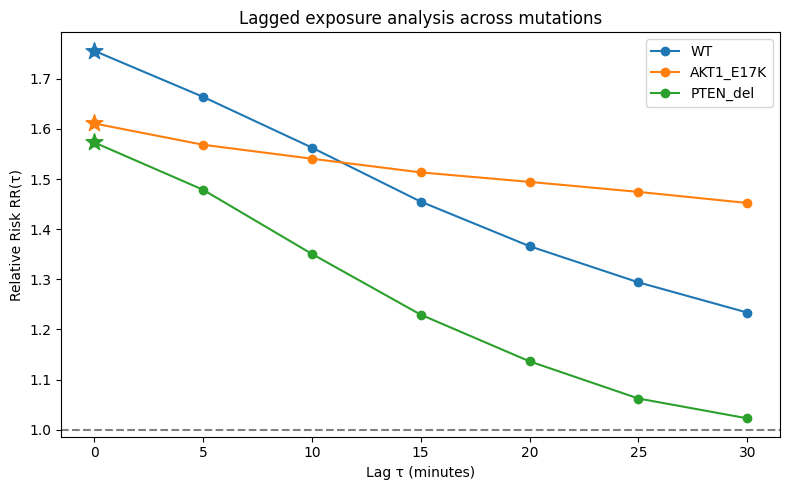

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))

for mut in selected_mutations:
    sub = lagged_df[lagged_df["mutation"] == mut]
    
    ax.plot(
        sub["tau_min"],
        sub["RR"],
        marker="o",
        label=mut
    )
    
    best_idx = sub["RR"].idxmax()
    best = sub.loc[best_idx]
    
    ax.scatter(
        best["tau_min"],
        best["RR"],
        marker="*",
        s=160,
        zorder=5
    )

ax.axhline(1, linestyle="--", color="gray")

ax.set_xlabel("Lag τ (minutes)")
ax.set_ylabel("Relative Risk RR(τ)")
ax.set_title("Lagged exposure analysis across mutations")
ax.legend()

plt.tight_layout()

plt.savefig(
    FINAL_OUTPUT_DIR / "lagged_exposure_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()